# Steam Game Recommender, Data Preparation

This notebook prepares **clean, leakage-safe, model-ready data** so that NRMS
can later be trained — exactly the way the paper trains them on MIND.

## 0. Configuration

In [ ]:
# ---- Environment ----
IN_COLAB = False
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    pass

# ---- Dataset identifiers ----
DATASET_SLUG = "antonkozyriev/game-recommendations-on-steam"
DATA_DIR     = "steam_data"          # raw downloaded files
OUTPUT_DIR   = "prepared_data"       # <-- all final model-ready files land here

# ---- Sampling (memory safety) ----
# We sample WHOLE USERS, not rows. Set to None to use every user (only on a big machine).
USER_SAMPLE_SIZE = 300_000            # number of users to keep after filtering-eligible pool
CHUNK_SIZE       = 2_000_000         # rows per chunk when streaming recommendations.csv
RANDOM_SEED      = 42

# ---- Sparsity filtering (applied iteratively until stable) ----
MIN_USER_INTERACTIONS = 5            # users need a history + a held-out item
MIN_ITEM_INTERACTIONS = 10           # drop near-cold items

# ---- History / candidate settings (mirror the paper) ----
MAX_HISTORY_LEN   = 50               # paper caps recently-viewed items at 50
NUM_NEG_SAMPLES   = 4                # paper uses 4 negatives per positive in training
NUM_EVAL_NEG      = 20               # negatives per positive in val/test impressions

# ---- Temporal split ratios (by global time, see Section 6) ----
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
# TEST_FRAC = remaining 0.10

# ---- Text settings ----
MAX_DESC_WORDS = 60                  # truncate game description; paper's item text is SHORT
                                     # (MIND titles + ~57.7-word category desc). Do NOT dump
                                     # the full Steam "about" text — it breaks the analogy
                                     # and overflows BERT's 512-token limit.

import random, os
random.seed(RANDOM_SEED)
print("Running in Colab:" , IN_COLAB)
print("Output folder    :", OUTPUT_DIR)

Running in Colab: True
Output folder    : prepared_data


## 1. Setup and download the dataset

In [ ]:
import os
import json
import zipfile
from pathlib import Path

# Install dependencies quietly
%pip -q install kaggle pandas numpy matplotlib tqdm

# =========================
# Kaggle API credentials
# =========================
KAGGLE_USERNAME = "aseelalmehmadi"
KAGGLE_KEY = "KGAT_4b6ac6742b67d5b8cc2decfc0c808dff"

# Dataset settings
DATASET_SLUG = "antonkozyriev/game-recommendations-on-steam"
DATA_DIR = "steam_game_recommendations_data"
OUTPUT_DIR = "steam_prepared_outputs"

# Create folders
Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

def have_raw_files():
    p = Path(DATA_DIR)
    return (p / "games.csv").exists() and (p / "recommendations.csv").exists()

# =========================
# Configure Kaggle API
# =========================
if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError("Please fill KAGGLE_USERNAME and KAGGLE_KEY before running this cell.")

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

kaggle_json_path = kaggle_dir / "kaggle.json"

with open(kaggle_json_path, "w") as f:
    json.dump(
        {
            "username": KAGGLE_USERNAME,
            "key": KAGGLE_KEY
        },
        f
    )

# Required permission for Kaggle API
try:
    os.chmod(kaggle_json_path, 0o600)
except Exception:
    pass

print("Kaggle API credentials are configured.")

# =========================
# Download and unzip dataset
# =========================
if not have_raw_files():
    !kaggle datasets download -d {DATASET_SLUG} -p {DATA_DIR} --force

    for zip_path in Path(DATA_DIR).glob("*.zip"):
        print("Unzipping:", zip_path.name)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)
else:
    print("Raw files already exist. Skipping download.")

# =========================
# Show downloaded files
# =========================
print("\nFiles in", DATA_DIR, ":")
for file_path in sorted(Path(DATA_DIR).glob("*")):
    size_mb = file_path.stat().st_size / 1024 / 1024
    print(f"  {file_path.name:30s} {size_mb:10.2f} MB")

Kaggle API credentials are configured.
Raw files already exist. Skipping download.

Files in steam_game_recommendations_data :
  game-recommendations-on-steam.zip     660.24 MB
  games.csv                            4.64 MB
  games_metadata.json                 16.74 MB
  recommendations.csv               1929.50 MB
  users.csv                          184.12 MB


### Sanity check 1 — expected files exist

In [ ]:
expected = ["games.csv", "games_metadata.json", "users.csv", "recommendations.csv"]
present  = {p.name for p in Path(DATA_DIR).glob("*")}
for f in expected:
    status = "OK" if f in present else "!! MISSING !!"
    print(f"  [{status}] {f}")
assert all(f in present for f in expected), "Some expected files are missing — re-download."
print("\nSanity check 1 passed: all four files present.")

  [OK] games.csv
  [OK] games_metadata.json
  [OK] users.csv
  [OK] recommendations.csv

Sanity check 1 passed: all four files present.


## 2. Load and inspect the item (game) metadata

In [ ]:
import pandas as pd
import numpy as np

# --- games.csv : structured metadata ---
games = pd.read_csv(Path(DATA_DIR) / "games.csv")
print("games.csv shape:", games.shape)
print("games.csv columns:", games.columns.tolist())
games.head()

games.csv shape: (50872, 13)
games.csv columns: ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [ ]:
# --- games_metadata.json : description + tags (line-delimited JSON) ---
# Loaded with lines=True; this file is small enough to hold in memory.
meta = pd.read_json(Path(DATA_DIR) / "games_metadata.json", lines=True)
print("games_metadata.json shape:", meta.shape)
print("games_metadata.json columns:", meta.columns.tolist())
meta.head()

games_metadata.json shape: (50872, 3)
games_metadata.json columns: ['app_id', 'description', 'tags']


,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."


In [ ]:
# --- Quick data-quality overview helper (reused below) ---
def overview(df, name):
    print("=" * 70)
    print(name, "  shape:", df.shape)
    print("-" * 70)

    miss = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    })

    print(miss)

    # Convert list/dict columns to strings only for duplicate checking
    df_for_duplicates = df.copy()

    for col in df_for_duplicates.columns:
        if df_for_duplicates[col].apply(lambda x: isinstance(x, (list, dict))).any():
            df_for_duplicates[col] = df_for_duplicates[col].apply(
                lambda x: json.dumps(x, sort_keys=True) if isinstance(x, (list, dict)) else x
            )

    print("Duplicated rows:", df_for_duplicates.duplicated().sum())
    print()

### Merge into a single item table

In [ ]:
# --- Normalise tags: ensure every row is a clean list of strings ---
def clean_tag_list(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip()]
    return []

meta["tags"] = meta["tags"].apply(clean_tag_list)
meta["description"] = meta["description"].fillna("").astype(str).str.strip()

# --- Merge structured metadata + text metadata ---
items = games.merge(meta, on="app_id", how="left")
items["tags"] = items["tags"].apply(lambda x: x if isinstance(x, list) else [])
items["description"] = items["description"].fillna("").astype(str)
items["title"] = items["title"].fillna("").astype(str).str.strip()

# --- Flag cold-start-metadata games (no usable text at all) ---
items["has_text"] = items["tags"].apply(len) > 0
items["n_tags"]   = items["tags"].apply(len)

print("Total games:", len(items))
print("Games with NO tags (unusable):", (~items["has_text"]).sum())
print("Games with at least some text:", items["has_text"].sum())
print("\nTag-count distribution:")
print(items["n_tags"].describe())
items[["app_id", "title", "description", "tags", "n_tags", "has_text"]].head()

Total games: 50872
Games with NO tags (unusable): 1244
Games with at least some text: 49628

Tag-count distribution:
count    50872.000000
mean        11.484019
std          7.256911
min          0.000000
25%          4.000000
50%         11.000000
75%         20.000000
max         20.000000
Name: n_tags, dtype: float64


,app_id,title,description,tags,n_tags,has_text
0,13500,Prince of Persia: Warrior Within™,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre...",20,True
1,22364,BRINK: Agents of Change,,[Action],1,True
2,113020,Monaco: What's Yours Is Mine,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St...",20,True
3,226560,Escape Dead Island,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P...",18,True
4,249050,Dungeon of the ENDLESS™,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra...",20,True


In [ ]:
# --- Build the item TEXT field (the MIND-title analog) ---
# Paper's item text = news title + ~50-word category description, fed via [SEP].
# Our item text     = game title + SHORT description + tag list.
# The LLM-generated tag descriptions are NOT added here — that is Phase 3.
# Here we only assemble the "base" text; Phase 3 will append the tag descriptions.

def truncate_words(text, max_words):
    words = text.split()
    return " ".join(words[:max_words])

items["description_short"] = items["description"].apply(
    lambda d: truncate_words(d, MAX_DESC_WORDS)
)
items["tags_str"] = items["tags"].apply(lambda ts: ", ".join(ts))

# base_text: what the encoder sees BEFORE the LLM tag-descriptions are appended in Phase 3.
# Format mirrors the paper's [SEP]-joined fields.
items["base_text"] = (
    items["title"].str.strip()
    + " [SEP] " + items["tags_str"].str.strip()
)

print("Example base_text values:\n")
for t in items["base_text"].head(3):
    print("-", t[:300], "\n")

Example base_text values:

- Prince of Persia: Warrior Within™ [SEP] Action, Adventure, Parkour, Third Person, Great Soundtrack, Singleplayer, Platformer, Time Travel, Atmospheric, Classic, Hack and Slash, Time Manipulation, Gore, Fantasy, Story Rich, Dark, Open World, Controller, Dark Fantasy, Puzzle 

- BRINK: Agents of Change [SEP] Action 

- Monaco: What's Yours Is Mine [SEP] Co-op, Stealth, Indie, Heist, Local Co-Op, Strategy, Online Co-Op, Top-Down, Action, Multiplayer, Crime, Casual, Great Soundtrack, Adventure, Pixel Graphics, Local Multiplayer, Controller, 2D, Singleplayer, Loot 



## 3. Load interactions (recommendations.csv) — memory-safe

In [ ]:
from tqdm.auto import tqdm

recs_path = Path(DATA_DIR) / "recommendations.csv"

# --- Peek at the header so we know the real column names ---
recs_head = pd.read_csv(recs_path, nrows=5)
print("recommendations.csv columns:", recs_head.columns.tolist())
recs_head

recommendations.csv columns: ['app_id', 'helpful', 'funny', 'date', 'is_recommended', 'hours', 'user_id', 'review_id']


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4


In [ ]:
# ---- PASS 1: collect the pool of user IDs (bounded memory) ----
# We only read the user_id column to keep this pass cheap.
user_pool = set()
n_rows_total = 0

reader = pd.read_csv(recs_path, usecols=["user_id"], chunksize=CHUNK_SIZE)
for chunk in tqdm(reader, desc="Pass 1: scanning users"):
    user_pool.update(chunk["user_id"].unique().tolist())
    n_rows_total += len(chunk)

print(f"\nTotal interaction rows in file : {n_rows_total:,}")
print(f"Total unique users in file     : {len(user_pool):,}")

Pass 1: scanning users: 0it [00:00, ?it/s]


Total interaction rows in file : 41,154,794
Total unique users in file     : 13,781,059


In [ ]:
# ---- Randomly sample whole users ----
user_pool = sorted(user_pool)  # sort for reproducibility before sampling
rng = random.Random(RANDOM_SEED)

if USER_SAMPLE_SIZE is not None and USER_SAMPLE_SIZE < len(user_pool):
    sampled_users = set(rng.sample(user_pool, USER_SAMPLE_SIZE))
else:
    sampled_users = set(user_pool)

print(f"Users selected for the experiment: {len(sampled_users):,}")

Users selected for the experiment: 300,000


In [ ]:
# ---- PASS 2: stream again, keep only rows for sampled users ----
keep_cols = ["user_id", "app_id", "is_recommended", "hours", "date"]
parts = []

reader = pd.read_csv(recs_path, usecols=keep_cols, chunksize=CHUNK_SIZE)
for chunk in tqdm(reader, desc="Pass 2: collecting sampled rows"):
    parts.append(chunk[chunk["user_id"].isin(sampled_users)])

interactions = pd.concat(parts, ignore_index=True)
del parts
print("Collected interactions shape:", interactions.shape)
interactions.head()

Pass 2: collecting sampled rows: 0it [00:00, ?it/s]

Collected interactions shape: (896414, 5)


,app_id,date,is_recommended,hours,user_id
0,376210,2021-03-01,True,114.2,944679
1,236850,2020-02-19,True,514.3,8639091
2,599140,2021-03-16,True,7.3,9112647
3,1361210,2022-11-30,False,165.5,12104501
4,394360,2022-08-13,True,179.7,12241689


### Sanity check 2 — interactions loaded correctly

In [ ]:
overview(interactions, "interactions (sampled users, raw)")
print("Label distribution (is_recommended):")
print(interactions["is_recommended"].value_counts(dropna=False))
print()
# is_recommended should be boolean-like; date should be parseable.
assert interactions["user_id"].isin(sampled_users).all(), "Found rows from non-sampled users!"
print("Sanity check 2 passed: all rows belong to sampled users.")

interactions (sampled users, raw)   shape: (896414, 5)
----------------------------------------------------------------------
                  dtype  missing_count  missing_pct
app_id            int64              0          0.0
date             object              0          0.0
is_recommended     bool              0          0.0
hours           float64              0          0.0
user_id           int64              0          0.0
Duplicated rows: 0

Label distribution (is_recommended):
is_recommended
True     768470
False    127944
Name: count, dtype: int64

Sanity check 2 passed: all rows belong to sampled users.


## 4. Clean the interaction table

In [ ]:
df = interactions.copy()

# 1) Type fixes
# is_recommended may arrive as bool or string; normalise to int 0/1.
if df["is_recommended"].dtype == bool:
    df["label"] = df["is_recommended"].astype(int)
else:
    df["label"] = (
        df["is_recommended"].astype(str).str.strip().str.lower()
        .isin(["true", "1", "yes"])
    ).astype(int)

df["hours"] = pd.to_numeric(df["hours"], errors="coerce").fillna(0.0)
df["date"]  = pd.to_datetime(df["date"], errors="coerce")

# 2) Drop rows without a usable date (needed for the temporal split)
before = len(df)
df = df[df["date"].notna()].copy()
print(f"Dropped {before - len(df):,} rows with no parseable date.")

# 3) Deduplicate (user_id, app_id): keep the latest review
before = len(df)
df = (df.sort_values("date")
        .drop_duplicates(subset=["user_id", "app_id"], keep="last")
        .reset_index(drop=True))
print(f"Dropped {before - len(df):,} duplicate (user, game) rows.")

# 4) Drop interactions whose game has no usable text
usable_games = set(items.loc[items["has_text"], "app_id"])
before = len(df)
df = df[df["app_id"].isin(usable_games)].copy()
print(f"Dropped {before - len(df):,} interactions with text-less games.")

print("\nClean interactions shape:", df.shape)
df[["user_id", "app_id", "label", "hours", "date"]].head()

Dropped 0 rows with no parseable date.
Dropped 1 duplicate (user, game) rows.
Dropped 451,201 interactions with text-less games.

Clean interactions shape: (445212, 6)


,user_id,app_id,label,hours,date
0,8616175,49600,1,19.3,2010-10-15
1,11448387,35140,1,4.9,2010-10-27
2,7442568,17470,1,40.4,2010-11-19
3,11224097,300,1,412.7,2010-11-19
5,11287488,17410,1,44.4,2010-11-19


## 5. Iterative sparsity filtering

In [ ]:
def iterative_filter(frame, min_user, min_item, max_iter=20):
    cur = frame.copy()
    for it in range(1, max_iter + 1):
        n_before = len(cur)

        item_counts = cur["app_id"].value_counts()
        good_items = item_counts[item_counts >= min_item].index
        cur = cur[cur["app_id"].isin(good_items)]

        user_counts = cur["user_id"].value_counts()
        good_users = user_counts[user_counts >= min_user].index
        cur = cur[cur["user_id"].isin(good_users)]

        n_after = len(cur)
        print(f"  iter {it:2d}: rows {n_before:,} -> {n_after:,} "
              f"| users={cur['user_id'].nunique():,} items={cur['app_id'].nunique():,}")
        if n_after == n_before:
            print("  converged.")
            break
    return cur.reset_index(drop=True)

print("Iterative filtering:")
df = iterative_filter(df, MIN_USER_INTERACTIONS, MIN_ITEM_INTERACTIONS)

Iterative filtering:
  iter  1: rows 445,212 -> 189,063 | users=16,692 items=5,404
  iter  2: rows 189,063 -> 175,430 | users=15,730 items=3,902
  iter  3: rows 175,430 -> 174,567 | users=15,666 items=3,834
  iter  4: rows 174,567 -> 174,462 | users=15,660 items=3,825
  iter  5: rows 174,462 -> 174,462 | users=15,660 items=3,825
  converged.


### Sanity check 3 — every user and item now meets the minimums

In [ ]:
uc = df["user_id"].value_counts()
ic = df["app_id"].value_counts()
assert uc.min() >= MIN_USER_INTERACTIONS, "A user is below the minimum!"
assert ic.min() >= MIN_ITEM_INTERACTIONS, "An item is below the minimum!"
print(f"Users : {df['user_id'].nunique():,}  (min interactions = {uc.min()})")
print(f"Items : {df['app_id'].nunique():,}  (min interactions = {ic.min()})")
print(f"Rows  : {len(df):,}")
density = len(df) / (df['user_id'].nunique() * df['app_id'].nunique())
print(f"Matrix density: {density:.6%}")
print("\nSanity check 3 passed.")

Users : 15,660  (min interactions = 5)
Items : 3,825  (min interactions = 10)
Rows  : 174,462
Matrix density: 0.291258%

Sanity check 3 passed.


## 6. Leakage-safe temporal split — **the most important section**

### Why a random split is wrong here

If we split interactions randomly, a user's **future** review can land in their **training
history** while a **past** review lands in **test**. The model would then "predict" the past
using the future. Metrics inflate, and the experiment is no longer a fair replication of the paper.
The paper's evaluation is per-impression and strictly time-ordered; we must respect time too.

In [ ]:
df = df.sort_values("date").reset_index(drop=True)

# Global timeline cut points
t_train_end = df["date"].quantile(TRAIN_FRAC)
t_val_end   = df["date"].quantile(TRAIN_FRAC + VAL_FRAC)

df["split"] = "test"
df.loc[df["date"] <= t_val_end,   "split"] = "val"
df.loc[df["date"] <= t_train_end, "split"] = "train"

print("Timeline cut points:")
print("  train: up to ", t_train_end)
print("  val  : up to ", t_val_end)
print("  test : after ", t_val_end)
print()
print("Rows per split:")
print(df["split"].value_counts())
print()
print("Label balance per split:")
print(df.groupby("split")["label"].mean().round(4))

Timeline cut points:
  train: up to  2021-09-19 00:00:00
  val  : up to  2022-04-22 00:00:00
  test : after  2022-04-22 00:00:00

Rows per split:
split
train    139600
val       17443
test      17419
Name: count, dtype: int64

Label balance per split:
split
test     0.8239
train    0.8454
val      0.8650
Name: label, dtype: float64


### Sanity check 4 — splits are strictly time-ordered (no overlap)

In [ ]:
max_train = df.loc[df.split == "train", "date"].max()
min_val   = df.loc[df.split == "val",   "date"].min()
max_val   = df.loc[df.split == "val",   "date"].max()
min_test  = df.loc[df.split == "test",  "date"].min()

print("max(train date) :", max_train)
print("min(val date)   :", min_val)
print("max(val date)   :", max_val)
print("min(test date)  :", min_test)

assert max_train <= min_val, "Train/val overlap in time!"
assert max_val   <= min_test, "Val/test overlap in time!"
print("\nSanity check 4 passed: train < val < test in time, no leakage across the cut.")

max(train date) : 2021-09-19 00:00:00
min(val date)   : 2021-09-20 00:00:00
max(val date)   : 2022-04-22 00:00:00
min(test date)  : 2022-04-23 00:00:00

Sanity check 4 passed: train < val < test in time, no leakage across the cut.


## 7. Build user histories and impression-style samples (with negative sampling)

In [ ]:
# --- Per-user chronological interaction lists ---
df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

# Map: user -> list of (app_id, label, date, split) in time order
from collections import defaultdict

user_events = defaultdict(list)
for row in df.itertuples(index=False):
    user_events[row.user_id].append(
        (row.app_id, int(row.label), row.date, row.split)
    )

# Global item pools by era (for leakage-safe negative sampling).
# An item "exists" from the first time it appears in interactions.
item_first_seen = df.groupby("app_id")["date"].min()
all_items_arr   = item_first_seen.index.to_numpy()

print("Users with events:", len(user_events))
print("Items available for sampling:", len(all_items_arr))

Users with events: 15660
Items available for sampling: 3825


In [ ]:
def sample_negatives(user_seen_set, candidate_date, n, rng_local):
    '''Sample n game IDs the user never reviewed and that existed by candidate_date.'''
    pool_mask = item_first_seen <= candidate_date          # item already existed
    pool = item_first_seen.index[pool_mask].to_numpy()
    negs = []
    attempts = 0
    # rejection sampling; cap attempts to stay fast even for very active users
    while len(negs) < n and attempts < n * 50:
        cand = pool[rng_local.randint(0, len(pool) - 1)]
        if cand not in user_seen_set and cand not in negs:
            negs.append(cand)
        attempts += 1
    return negs


def build_samples(split_name, neg_k):
    '''
    Build (user, history, candidate, label) rows for one split.
    - Positives  : the user's label==1 reviews dated within this split.
    - Negatives  : the user's label==0 reviews in this split  +  sampled un-reviewed games.
    - History    : user's positively-reviewed games strictly BEFORE the candidate date.
    '''
    rng_local = random.Random(RANDOM_SEED + hash(split_name) % 1000)
    rows = []
    skipped_no_history = 0

    for uid, events in user_events.items():
        # full set of games this user ever touched (for negative exclusion)
        user_seen = {e[0] for e in events}

        for app_id, label, cdate, csplit in events:
            if csplit != split_name:
                continue

            # history = positively-reviewed games strictly before this candidate
            history = [e[0] for e in events if e[2] < cdate and e[1] == 1]
            history = history[-MAX_HISTORY_LEN:]

            # honest behaviour: no prior history -> cannot personalise -> skip candidate
            if len(history) == 0:
                skipped_no_history += 1
                continue

            # the observed review itself (positive OR explicit negative)
            rows.append({
                "user_id": uid,
                "history": history,
                "candidate": app_id,
                "label": label,
                "date": cdate,
                "neg_type": "observed",
            })

            # for positives, add sampled negatives to form an "impression"
            if label == 1:
                negs = sample_negatives(user_seen, cdate, neg_k, rng_local)
                for ng in negs:
                    rows.append({
                        "user_id": uid,
                        "history": history,
                        "candidate": ng,
                        "label": 0,
                        "date": cdate,
                        "neg_type": "sampled",
                    })

    print(f"  [{split_name}] candidates skipped (no prior history): {skipped_no_history:,}")
    return pd.DataFrame(rows)


print("Building train samples...")
train_samples = build_samples("train", NUM_NEG_SAMPLES)
print("Building val samples...")
val_samples   = build_samples("val",   NUM_EVAL_NEG)
print("Building test samples...")
test_samples  = build_samples("test",  NUM_EVAL_NEG)

for name, s in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    print(f"  {name:5s}: {len(s):,} rows | "
          f"pos={int((s.label==1).sum()):,} neg={int((s.label==0).sum()):,} | "
          f"users={s['user_id'].nunique():,}")

Building train samples...
  [train] candidates skipped (no prior history): 21,002
Building val samples...
  [val] candidates skipped (no prior history): 848
Building test samples...
  [test] candidates skipped (no prior history): 560
  train: 519,002 rows | pos=100,101 neg=418,901 | users=14,380
  val  : 303,535 rows | pos=14,347 neg=289,188 | users=6,705
  test : 294,159 rows | pos=13,865 neg=280,294 | users=6,363


### Group val/test into impressions

In [ ]:
def add_impression_ids(samples):
    '''Each (user, candidate-date) for an observed positive defines one impression.'''
    s = samples.copy()
    # an impression is keyed by user + the date of the observed positive it was built around
    s["impression_id"] = (
        s["user_id"].astype(str) + "_" + s["date"].astype("int64").astype(str)
    )
    # map to compact integer ids
    uniq = {k: i for i, k in enumerate(s["impression_id"].unique())}
    s["impression_id"] = s["impression_id"].map(uniq)
    return s

val_samples  = add_impression_ids(val_samples)
test_samples = add_impression_ids(test_samples)

print("Val impressions :", val_samples["impression_id"].nunique())
print("Test impressions:", test_samples["impression_id"].nunique())
# Typical impression size = 1 positive + NUM_EVAL_NEG negatives (minus any rejection shortfall)
print("\nExample test impression sizes:")
print(test_samples.groupby("impression_id").size().describe())

Val impressions : 14598
Test impressions: 14717

Example test impression sizes:
count    14717.000000
mean        19.987701
std         16.618656
min          1.000000
25%         21.000000
50%         21.000000
75%         21.000000
max        442.000000
dtype: float64


### Sanity check 5 — no leakage in histories, no train/test user-candidate overlap

In [ ]:
# 5a) every history item must be dated strictly before its candidate -> checked by construction,
#     but we re-verify on a random subsample for safety.
sample_check = test_samples.sample(min(2000, len(test_samples)), random_state=RANDOM_SEED)
ok = True
for r in sample_check.itertuples(index=False):
    # all history items must have appeared before candidate date for this user
    uev = {e[0]: e[2] for e in user_events[r.user_id]}
    for h in r.history:
        if uev.get(h) is not None and uev[h] >= r.date:
            ok = False
            break
assert ok, "LEAKAGE: a history item is dated at/after its candidate!"
print("5a passed: histories are strictly in the past.")

# 5b) the same (user, candidate, label=1 observed) positive should not appear in two splits
def pos_keys(s):
    p = s[(s.label == 1) & (s.neg_type == "observed")]
    return set(zip(p.user_id, p.candidate))

assert len(pos_keys(train_samples) & pos_keys(test_samples)) == 0, "Train/test positive overlap!"
assert len(pos_keys(train_samples) & pos_keys(val_samples))  == 0, "Train/val positive overlap!"
print("5b passed: no observed-positive leaks across splits.")
print("\nSanity check 5 passed.")

5a passed: histories are strictly in the past.
5b passed: no observed-positive leaks across splits.

Sanity check 5 passed.


## 8. Finalise the item table and export the unique tag list for the LLM (Phase 3)

In [ ]:
# Games that survived filtering and actually appear in interactions
final_item_ids = set(df["app_id"].unique())
item_table = items[items["app_id"].isin(final_item_ids)].copy()

# Keep only columns each field is ALLOWED to be used for
item_table = item_table[[
    "app_id", "title", "description_short", "tags", "tags_str", "base_text",
    # signal/diagnostic columns (NOT to be used as encoder text):
    "positive_ratio", "user_reviews", "price_final", "date_release",
]].reset_index(drop=True)

print("Final item table shape:", item_table.shape)

# --- Unique tag list across the final games ---
tag_counter = defaultdict(int)
for tags in item_table["tags"]:
    for t in tags:
        tag_counter[t] += 1

tag_df = (pd.DataFrame({"tag": list(tag_counter.keys()),
                        "game_count": list(tag_counter.values())})
            .sort_values("game_count", ascending=False)
            .reset_index(drop=True))

print("Unique tags across final games:", len(tag_df))
tag_df.head(20)

Final item table shape: (3825, 10)
Unique tags across final games: 433


,tag,game_count
0,Singleplayer,3125
1,Action,2326
2,Adventure,2207
3,Indie,2182
4,Multiplayer,1542
5,Atmospheric,1392
6,Great Soundtrack,1284
7,Story Rich,1242
8,Casual,1214
9,2D,1141


### Sanity check 6 — every interaction game has a row in the item table

In [ ]:
missing = final_item_ids - set(item_table["app_id"])
assert len(missing) == 0, f"{len(missing)} interaction games missing from item table!"
assert item_table["base_text"].str.len().min() > 0, "Some item has empty base_text!"
print("Sanity check 6 passed: item table is complete and every game has text.")
print(f"Final games: {len(item_table):,}  |  Unique tags: {len(tag_df):,}")

Sanity check 6 passed: item table is complete and every game has text.
Final games: 3,825  |  Unique tags: 433


## 9. Summary statistics and plots

A compact picture of the prepared dataset — analogous to Table 1 in the paper
(`#User #News #Impression #Click`).

In [ ]:
import matplotlib.pyplot as plt

# --- Summary table (paper's Table 1 analog) ---
summary = {
    "#Users (final)":            df["user_id"].nunique(),
    "#Games (final)":            len(item_table),
    "#Interactions (final)":     len(df),
    "#Unique tags":              len(tag_df),
    "Matrix density":            f"{len(df)/(df['user_id'].nunique()*len(item_table)):.5%}",
    "Overall recommend rate":    f"{df['label'].mean():.3%}",
    "#Train samples":            len(train_samples),
    "#Val samples":              len(val_samples),
    "#Test samples":             len(test_samples),
    "#Val impressions":          val_samples["impression_id"].nunique(),
    "#Test impressions":         test_samples["impression_id"].nunique(),
}
summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
print(summary_df.to_string(index=False))

                Metric    Value
        #Users (final)    15660
        #Games (final)     3825
 #Interactions (final)   174462
          #Unique tags      433
        Matrix density 0.29126%
Overall recommend rate  84.519%
        #Train samples   519002
          #Val samples   303535
         #Test samples   294159
      #Val impressions    14598
     #Test impressions    14717


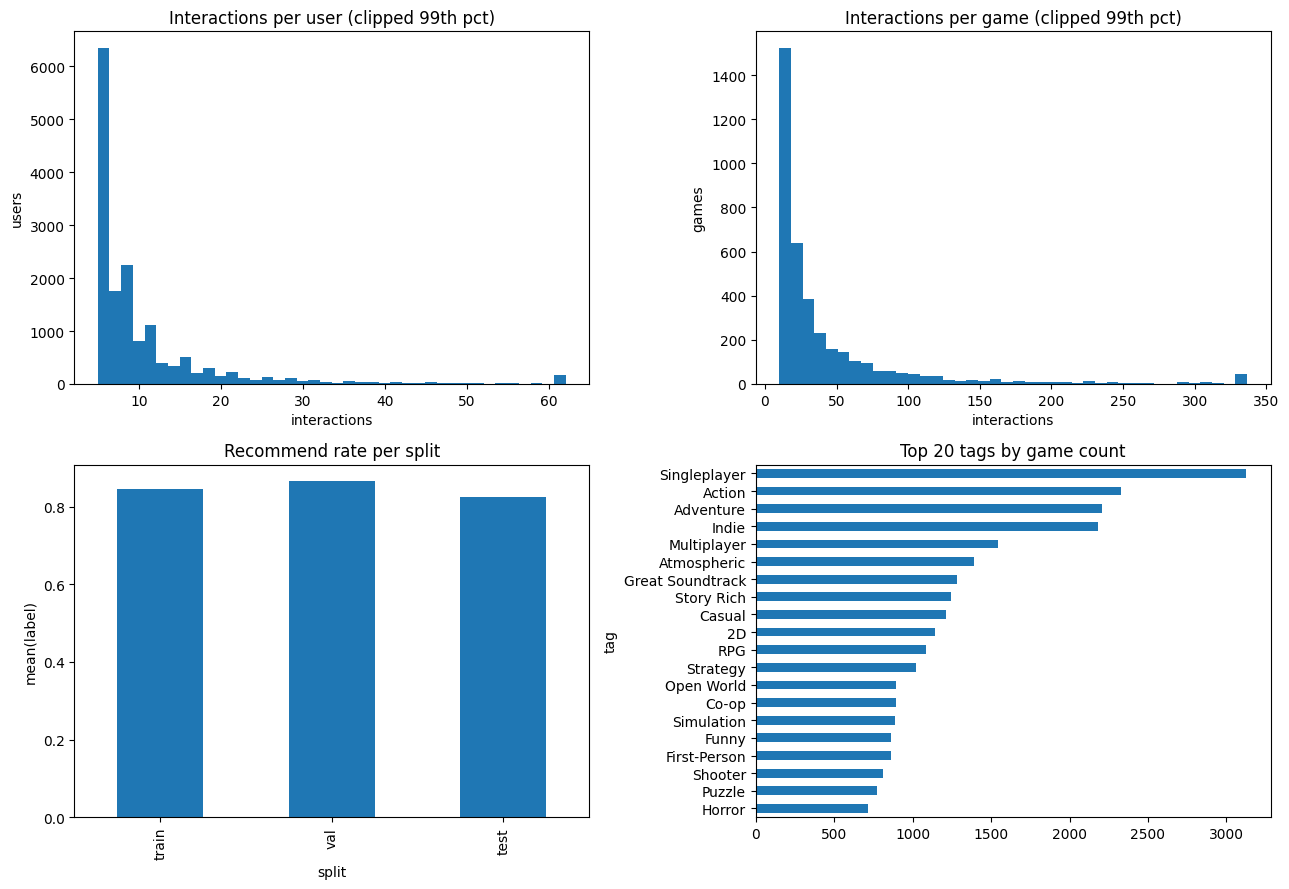

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) interactions per user
upc = df.groupby("user_id").size()
axes[0,0].hist(upc.clip(upper=upc.quantile(0.99)), bins=40)
axes[0,0].set_title("Interactions per user (clipped 99th pct)")
axes[0,0].set_xlabel("interactions"); axes[0,0].set_ylabel("users")

# (b) interactions per game (popularity bias)
ipc = df.groupby("app_id").size()
axes[0,1].hist(ipc.clip(upper=ipc.quantile(0.99)), bins=40)
axes[0,1].set_title("Interactions per game (clipped 99th pct)")
axes[0,1].set_xlabel("interactions"); axes[0,1].set_ylabel("games")

# (c) label balance per split
df.groupby("split")["label"].mean().reindex(["train","val","test"]).plot(
    kind="bar", ax=axes[1,0])
axes[1,0].set_title("Recommend rate per split")
axes[1,0].set_ylabel("mean(label)")

# (d) top tags
tag_df.head(20).set_index("tag")["game_count"].plot(kind="barh", ax=axes[1,1])
axes[1,1].invert_yaxis()
axes[1,1].set_title("Top 20 tags by game count")

plt.tight_layout()
plt.show()

## 10. Save all model-ready files

In [ ]:
out = Path(OUTPUT_DIR)
out.mkdir(parents=True, exist_ok=True)

# --- 1. Item / game table (MIND news.tsv analog) ---
item_table.to_parquet(out / "items.parquet", index=False)
item_table.drop(columns=["tags"]).to_csv(out / "items.csv", index=False)  # tags_str kept as string

# --- 2. Interaction-level clean table (full, with split labels) ---
df[["user_id", "app_id", "label", "hours", "date", "split"]].to_parquet(
    out / "interactions_clean.parquet", index=False)

# --- 3. Train / val / test sample files (MIND behaviors.tsv analog) ---
for name, s in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    s.to_parquet(out / f"samples_{name}.parquet", index=False)
    # JSONL copy (lists survive as JSON arrays) — easy to load anywhere
    s.to_json(out / f"samples_{name}.jsonl", orient="records", lines=True)

# --- 4. Unique tag list for the LLM description step (Phase 3) ---
tag_df.to_csv(out / "tags_unique.csv", index=False)

# --- 5. Summary table ---
summary_df.to_csv(out / "summary_stats.csv", index=False)

# --- 6. A small JSON manifest describing what was produced ---
manifest = {
    "random_seed": RANDOM_SEED,
    "user_sample_size": USER_SAMPLE_SIZE,
    "min_user_interactions": MIN_USER_INTERACTIONS,
    "min_item_interactions": MIN_ITEM_INTERACTIONS,
    "max_history_len": MAX_HISTORY_LEN,
    "num_neg_samples_train": NUM_NEG_SAMPLES,
    "num_eval_neg": NUM_EVAL_NEG,
    "train_frac": TRAIN_FRAC, "val_frac": VAL_FRAC,
    "n_users_final": int(df["user_id"].nunique()),
    "n_items_final": int(len(item_table)),
    "n_interactions_final": int(len(df)),
    "n_unique_tags": int(len(tag_df)),
    "files": sorted(p.name for p in out.glob("*")),
}
with open(out / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print("Saved files in", out.resolve(), ":")
for p in sorted(out.glob("*")):
    print(f"  {p.name:28s} {p.stat().st_size/1024:10.1f} KB")

Saved files in /content/steam_prepared_outputs :
  interactions_clean.parquet       1123.3 KB
  items.csv                        2613.0 KB
  items.parquet                    1333.2 KB
  manifest.json                       0.6 KB
  samples_test.jsonl              62450.8 KB
  samples_test.parquet             1286.1 KB
  samples_train.jsonl             84372.6 KB
  samples_train.parquet            2811.8 KB
  samples_val.jsonl               60374.5 KB
  samples_val.parquet              1237.9 KB
  summary_stats.csv                   0.3 KB
  tags_unique.csv                     6.0 KB


### Sanity check 7 — reload every saved file and verify it is intact

In [ ]:
# Reload and re-verify the critical files
chk_items = pd.read_parquet(out / "items.parquet")
chk_train = pd.read_parquet(out / "samples_train.parquet")
chk_test  = pd.read_parquet(out / "samples_test.parquet")
chk_tags  = pd.read_csv(out / "tags_unique.csv")

assert len(chk_items) == len(item_table),     "items.parquet row count mismatch!"
assert len(chk_train) == len(train_samples),  "samples_train.parquet row count mismatch!"
assert isinstance(chk_train["history"].iloc[0], (list, np.ndarray)), "history column lost its list type!"
assert chk_test["candidate"].isin(set(chk_items["app_id"])).all(), "A test candidate is not in the item table!"
assert chk_tags["tag"].is_unique, "Tag list has duplicates!"

print("Sanity check 7 passed: all output files reload correctly and are internally consistent.")
print("\n  DATA PREPARATION COMPLETE.")
print("  Next phase: feed tags_unique.csv to the LLM to generate genre/tag descriptions,")
print("  then append those descriptions to each game's base_text to form the augmented input.")

Sanity check 7 passed: all output files reload correctly and are internally consistent.

  DATA PREPARATION COMPLETE.
  Next phase: feed tags_unique.csv to the LLM to generate genre/tag descriptions,
  then append those descriptions to each game's base_text to form the augmented input.


In [ ]:
# How many tags-empty games are there? How many interactions do they get?
tags_empty = items[items["n_tags"] == 0]["app_id"]
desc_empty = items[items["description"].str.len() == 0]["app_id"]
both_empty = items[~items["has_text"]]["app_id"]

print(f"Games with no tags          : {len(tags_empty):,}")
print(f"Games with no description   : {len(desc_empty):,}")
print(f"Games with neither          : {len(both_empty):,}")

# Top no-tag games by interaction count in the sample
top_notag = (interactions[interactions["app_id"].isin(tags_empty)]
             .groupby("app_id").size()
             .sort_values(ascending=False).head(10))
top_notag = top_notag.to_frame("interactions").merge(
    games[["app_id","title"]], left_index=True, right_on="app_id")
print("\nTop interaction-heavy games with NO tags:")
print(top_notag)

Games with no tags          : 1,244
Games with no description   : 10,373
Games with neither          : 1,244

Top interaction-heavy games with NO tags:
       interactions   app_id                             title
47380          6858      440                   Team Fortress 2
13173          5954   252490                              Rust
14163          4876  1091500                    Cyberpunk 2077
13176          4820      570                            Dota 2
14398          4762      730  Counter-Strike: Global Offensive
15273          4522   444090                         Paladins®
12800          4505   292030         The Witcher® 3: Wild Hunt
13181          4249   377160                         Fallout 4
14535          4198   359550   Tom Clancy's Rainbow Six® Siege
47791          4103   431960                  Wallpaper Engine
